# **K - Nearest Neighbours**

## 1. Data Understanding & Exploratory Data Analysis

### 1.1 Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1.2 Import & Understanding Data

In [2]:
# Import Assignment-2_Data.csv
assignment = pd.read_csv('Assignment-2_Data.csv')


In [3]:
# Tampilkan 5 baris teratas
print('\n5 baris teratas:')
assignment.head()


5 baris teratas:


,Id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,1001,999.0,management,married,tertiary,no,2143.0,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,1002,44.0,technician,single,secondary,no,29.0,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,1003,33.0,entrepreneur,married,secondary,no,2.0,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,1004,47.0,blue-collar,married,unknown,no,1506.0,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,1005,33.0,unknown,single,unknown,no,1.0,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
# Tampilkan informasi dataste
print('\nInformasi dataset:')
assignment.info()


Informasi dataset:
<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Id         45211 non-null  int64  
 1   age        45202 non-null  float64
 2   job        45211 non-null  str    
 3   marital    45211 non-null  str    
 4   education  45211 non-null  str    
 5   default    45211 non-null  str    
 6   balance    45208 non-null  float64
 7   housing    45211 non-null  str    
 8   loan       45211 non-null  str    
 9   contact    45211 non-null  str    
 10  day        45211 non-null  int64  
 11  month      45211 non-null  str    
 12  duration   45211 non-null  int64  
 13  campaign   45211 non-null  int64  
 14  pdays      45211 non-null  int64  
 15  previous   45211 non-null  int64  
 16  poutcome   45211 non-null  str    
 17  y          45211 non-null  str    
dtypes: float64(2), int64(6), str(10)
memory usage: 6.2 MB


In [5]:
# Tampilkan jumlah sample dan fitur dataset
print('\nJumlah sampel dan fitur dataset:')
print('Jumlah baris:', assignment.shape[0])
print('Jumlah kolom:', assignment.shape[1])


Jumlah sampel dan fitur dataset:
Jumlah baris: 45211
Jumlah kolom: 18


In [6]:
# Tampilkan nilai unik per fitur
print('\nNilai unik per fitur:')
for col in assignment.columns:
    print(f'=== Nilai Unik Fitur {col} ===')
    print('Jumlah nilai unik:', assignment[col].nunique())
    print(f'Nilai unik fitur {col}:', assignment[col].unique())
    print('-' * 30) # Garis pembatas agar lebih rapi


Nilai unik per fitur:
=== Nilai Unik Fitur Id ===
Jumlah nilai unik: 45211
Nilai unik fitur Id: [ 1001  1002  1003 ... 46209 46210 46211]
------------------------------
=== Nilai Unik Fitur age ===
Jumlah nilai unik: 79
Nilai unik fitur age: [999.  44.  33.  47.  35.  28.  nan  58.  43.  41.  29.  53.  57.  51.
  45.  60.  56.  32.  25.  40.  39.  52.  46.  36.  49.  59.  37.  50.
  54.  55.  48.  31.  42.  30.  27.  34.  38.  23.  26.  61.  22.  24.
  21.  20.  66.  62.  83.  75.  67.  70.  65.  68.  64.  69.  72.  71.
  19.  76.  85.  63.  90.  82.  73.  74.  78.  80.  94.  79.  77.  86.
  95.  81.  18.  89.  84.  87.  92.  93.  88.  -1.]
------------------------------
=== Nilai Unik Fitur job ===
Jumlah nilai unik: 12
Nilai unik fitur job: <StringArray>
[   'management',    'technician',  'entrepreneur',   'blue-collar',
       'unknown',       'retired',        'admin.',      'services',
 'self-employed',    'unemployed',     'housemaid',       'student']
Length: 12, dtype: str
--

In [7]:
# Fungsi cek nilai unik per fitur
def unique_values(feature_name):
    print(f'=== Nilai Unik Fitur {feature_name} ===')
    print('Jumlah nilai unik:', assignment[feature_name].nunique())
    print('Nilai unik:', assignment[feature_name].unique())

In [8]:
# Pembagian tipe data fitur 
num_cols = assignment.select_dtypes(include=['int64', 'float64']).columns
cat_cols = assignment.select_dtypes(include=['object', 'category']).columns

print('Fitur numerik:', num_cols, '\n')
print('Fitur kategori:', cat_cols)

Fitur numerik: Index(['Id', 'age', 'balance', 'day', 'duration', 'campaign', 'pdays',
       'previous'],
      dtype='str') 

Fitur kategori: Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'y'],
      dtype='str')


/tmp/ipykernel_30912/2121670043.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = assignment.select_dtypes(include=['object', 'category']).columns


In [9]:
# Panggil fungsi unique_values 
unique_values('Id')

=== Nilai Unik Fitur Id ===
Jumlah nilai unik: 45211
Nilai unik: [ 1001  1002  1003 ... 46209 46210 46211]


### 1.3 Missing Value dan Data Duplikat

#### 1.3.1 Missing Value

In [10]:
# Tampilkan total missing value
print('Total missing value:', assignment.isnull().sum().sum())

Total missing value: 12


In [11]:
# Tampilkan total missing value per fitur
print('\nJumlah missing value per fitur:')
assignment.isnull().sum()


Jumlah missing value per fitur:


Id           0
age          9
job          0
marital      0
education    0
default      0
balance      3
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [12]:
# Tampilkan baris yang memiliki missing value 
assignment[assignment.isnull().any(axis=1)]

,Id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
7,1008,NaN,entrepreneur,divorced,tertiary,yes,NaN,yes,no,unknown,5,may,380,1,-1,0,unknown,no
8,1009,58.0,retired,married,primary,no,NaN,yes,no,unknown,5,may,50,1,-1,0,unknown,no
9,1010,43.0,technician,single,secondary,no,NaN,yes,no,unknown,5,may,55,1,-1,0,unknown,no
53,1054,NaN,admin.,single,secondary,no,-76.0,yes,no,unknown,5,may,787,1,-1,0,unknown,no
54,1055,NaN,technician,single,secondary,no,-103.0,yes,yes,unknown,5,may,145,1,-1,0,unknown,no
55,1056,NaN,entrepreneur,single,tertiary,no,243.0,no,yes,unknown,5,may,174,1,-1,0,unknown,no
56,1057,NaN,management,single,tertiary,no,424.0,yes,no,unknown,5,may,104,1,-1,0,unknown,no
57,1058,NaN,blue-collar,married,unknown,no,306.0,yes,no,unknown,5,may,13,1,-1,0,unknown,no
58,1059,NaN,blue-collar,single,unknown,no,24.0,yes,no,unknown,5,may,185,1,-1,0,unknown,no
59,1060,NaN,services,married,primary,no,179.0,yes,no,unknown,5,may,1778,1,-1,0,unknown,no


#### 1.3.2 Data Duplikat

In [13]:
# Tampilkan total data duplikat 
print('Total data duplikat:', assignment.duplicated().sum())

Total data duplikat: 0


### 1.4 Exploratory Data Analysis

#### 1.4.1 Statistik Dataset

In [14]:
# Tampilkan statistik dataset fitur numerik
assignment.describe()

,Id,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45202.000000,45208.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,23606.000000,40.954714,1362.346620,15.806419,258.163080,2.763841,40.197828,0.580323
std,13051.435847,11.539144,3044.852387,8.322476,257.527812,3.098021,100.128746,2.303441
min,1001.000000,-1.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,12303.500000,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,23606.000000,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,34908.500000,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,46211.000000,999.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


Pada fitur numerik, cenderung memiliki standar deviation yang besar. Dengan selisih nilai minimum dan maksimum lumayan jauh. Sehingga, ada kemungkinan terdeteksi outlier.

#### 1.4.2 Penyebaran Dataset

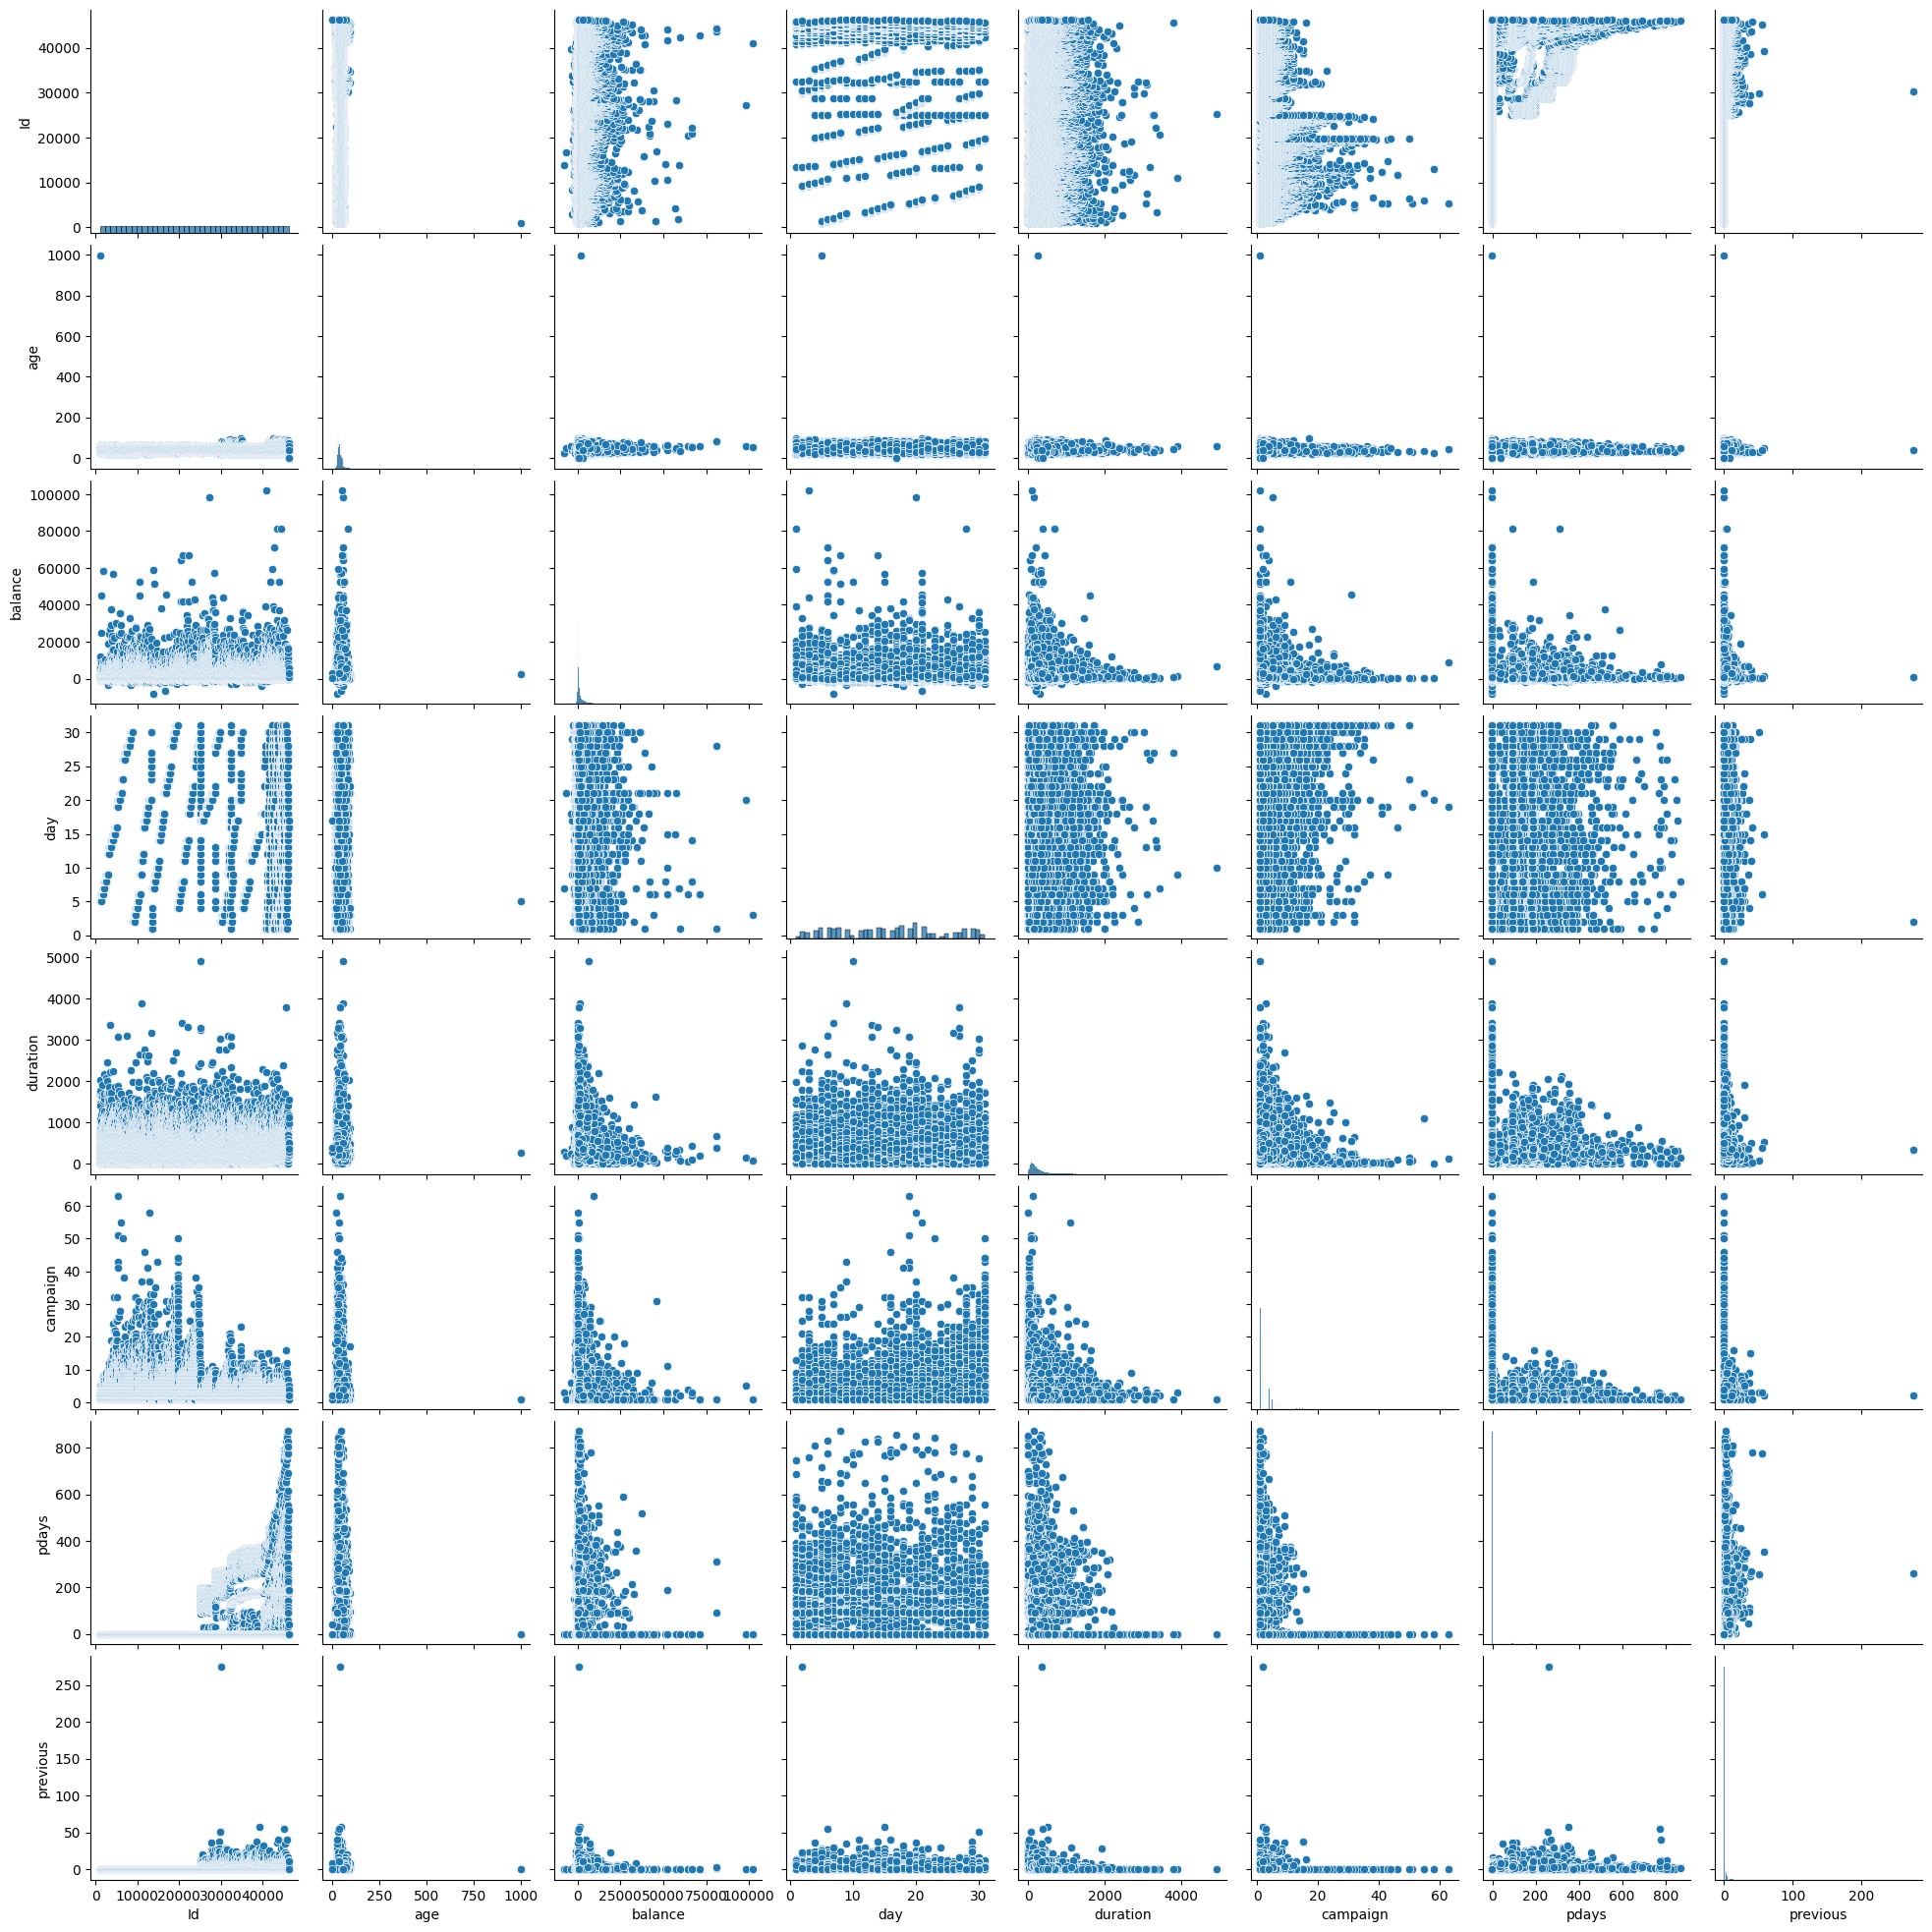

In [15]:
# Grafik scateerplot antar fitur
sns.pairplot(assignment)
plt.show()

Dari scatterplot diatas, setelah dianalisis, tidak ada pembagian kelompok yang jelas antar fitur.

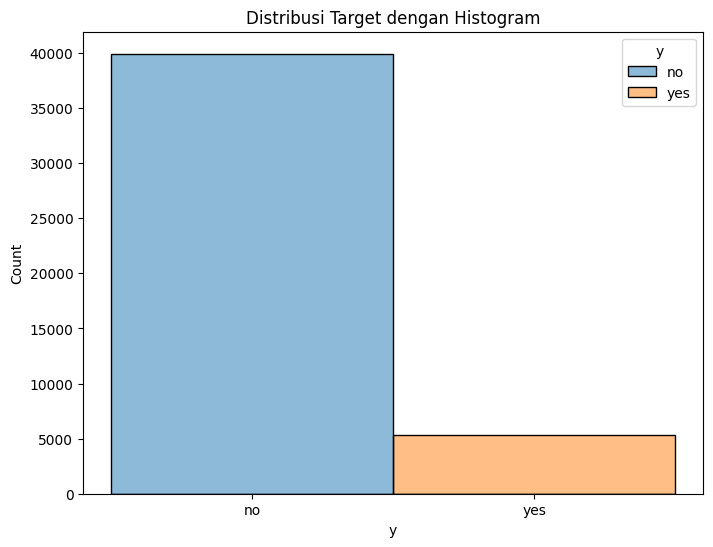

In [16]:
# Histogram fitur target
plt.figure(figsize=(8,6))
plt.title('Distribusi Target dengan Histogram')
sns.histplot(data=assignment, x='y', hue='y', bins=2)
plt.show()

Penyebaran target tidak seimbang. Dimana target 'no' mendominasi dengan range 0 - 40000. Sedangkan, target 'yes' hanya memiliki range 0 - 5000.

In [17]:
print(cat_cols)
print(num_cols)

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'y'],
      dtype='str')
Index(['Id', 'age', 'balance', 'day', 'duration', 'campaign', 'pdays',
       'previous'],
      dtype='str')


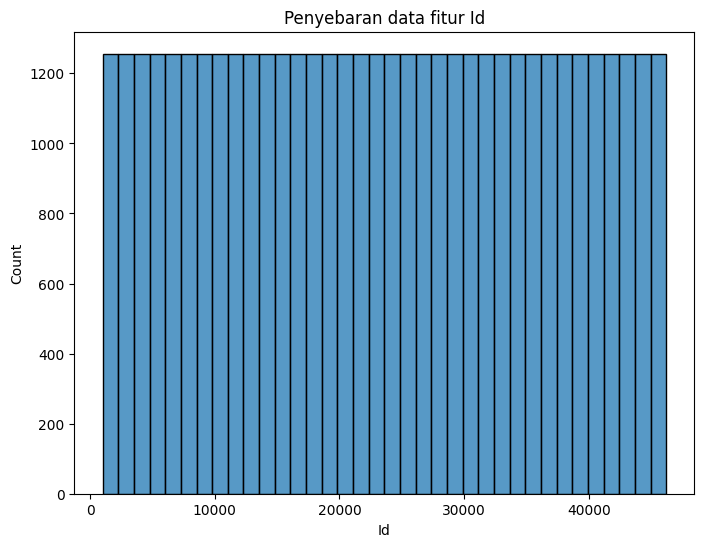

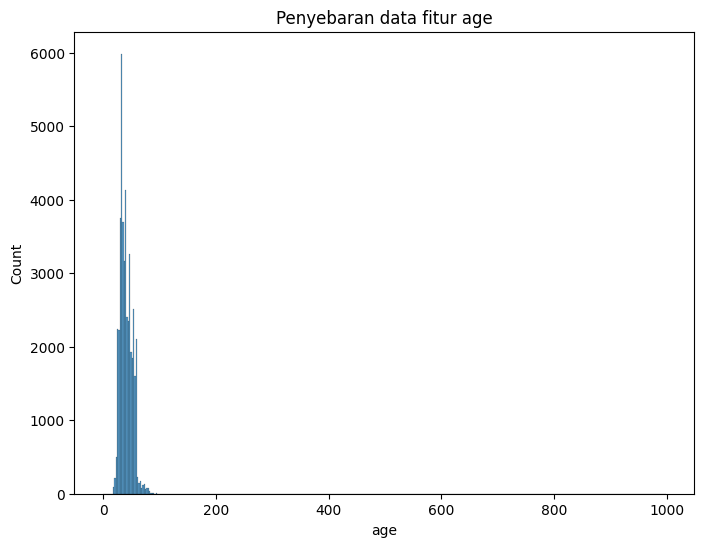

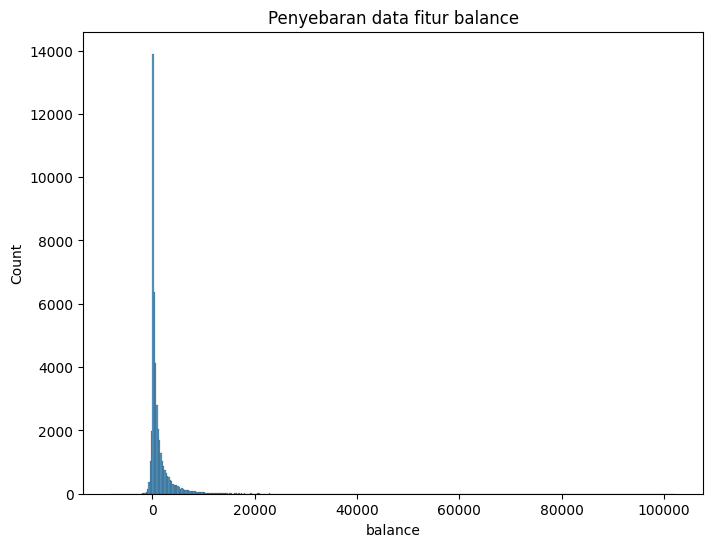

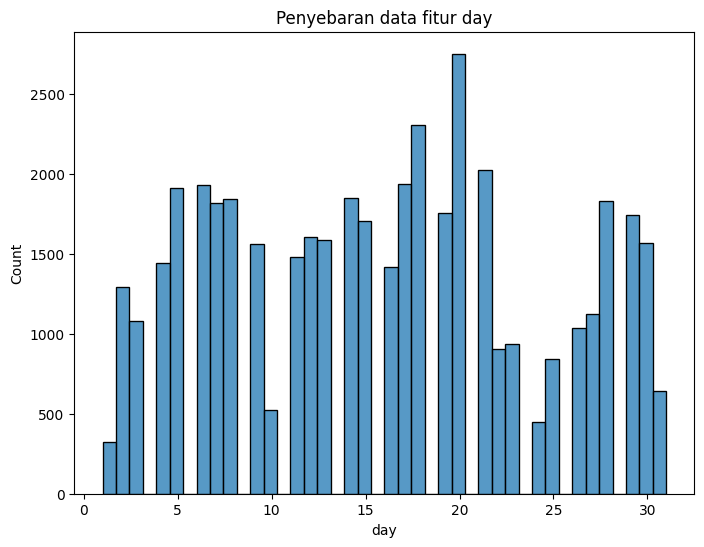

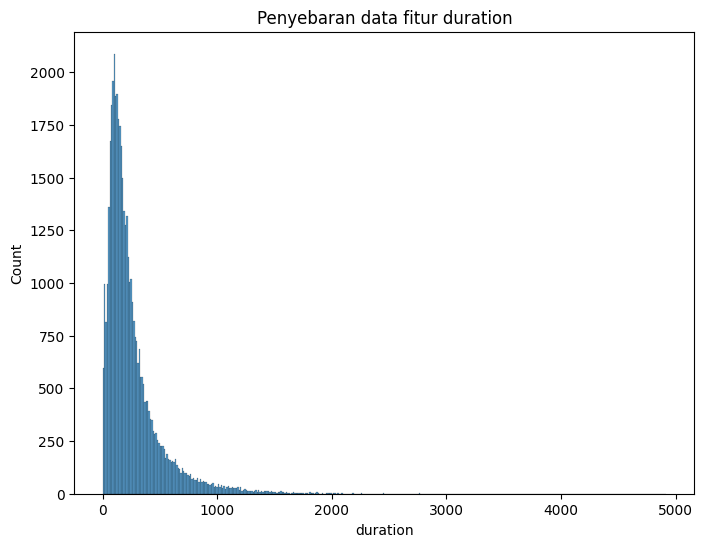

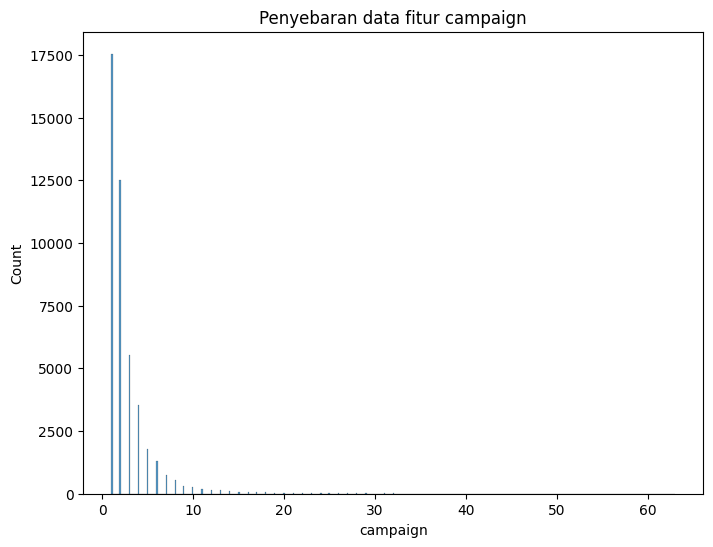

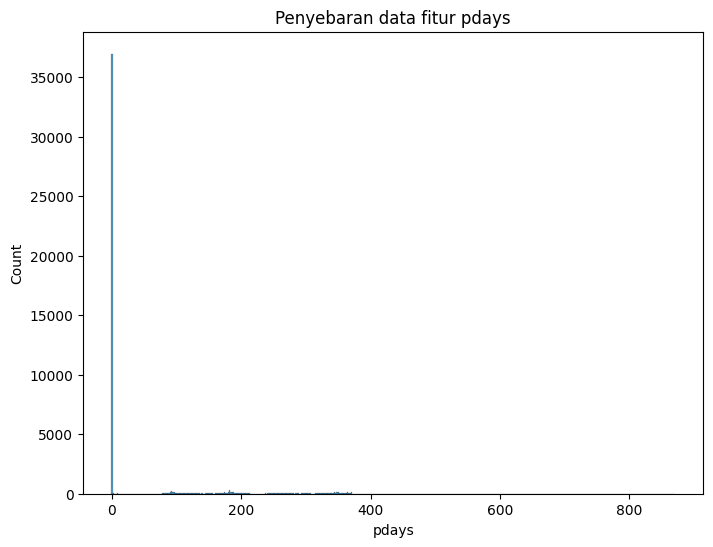

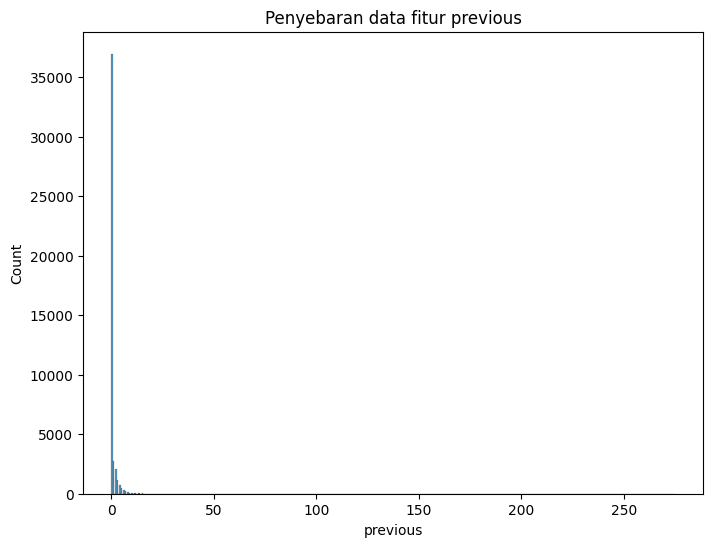

In [18]:
# Penyebaran data numerik
for col in num_cols:
    plt.figure(figsize=(8,6))
    sns.histplot(x=assignment[col])
    plt.title(f'Penyebaran data fitur {col}')
    plt.show()

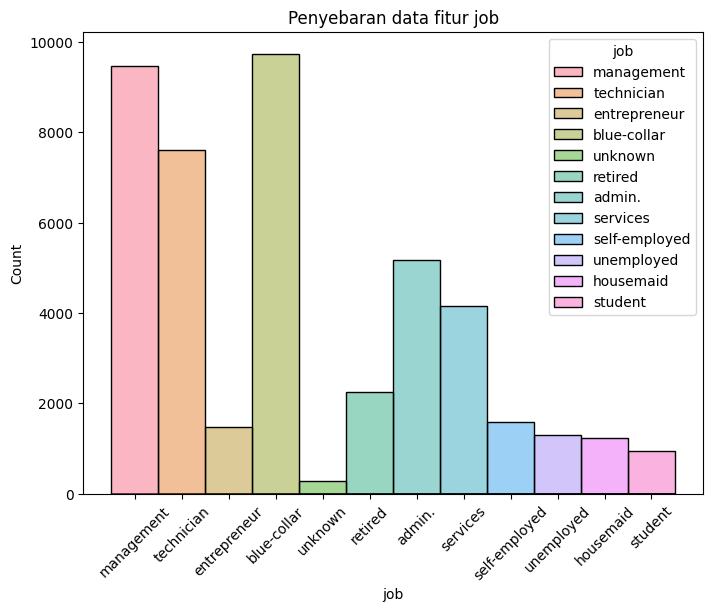

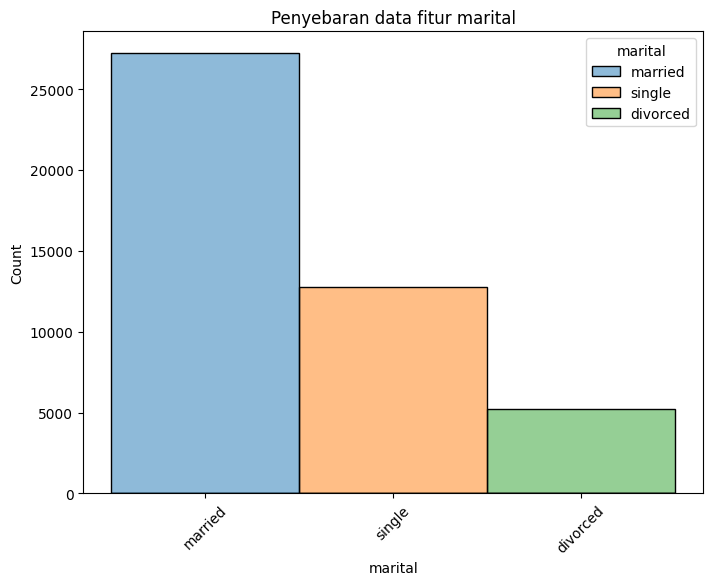

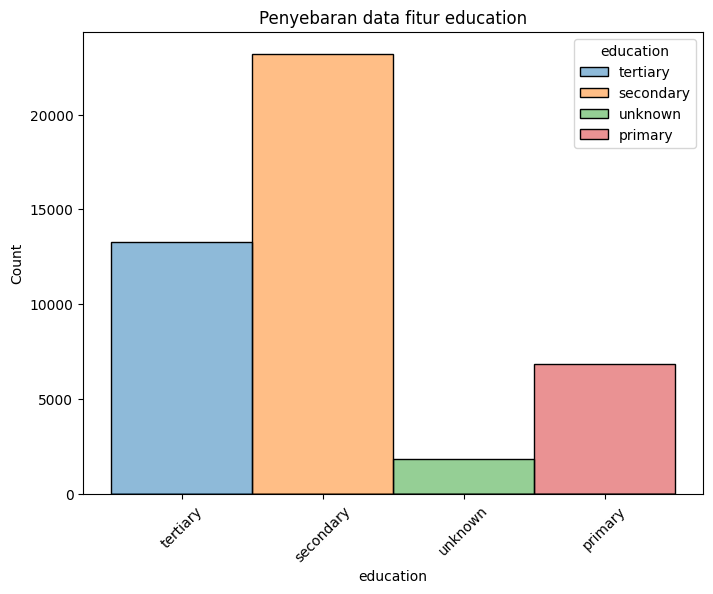

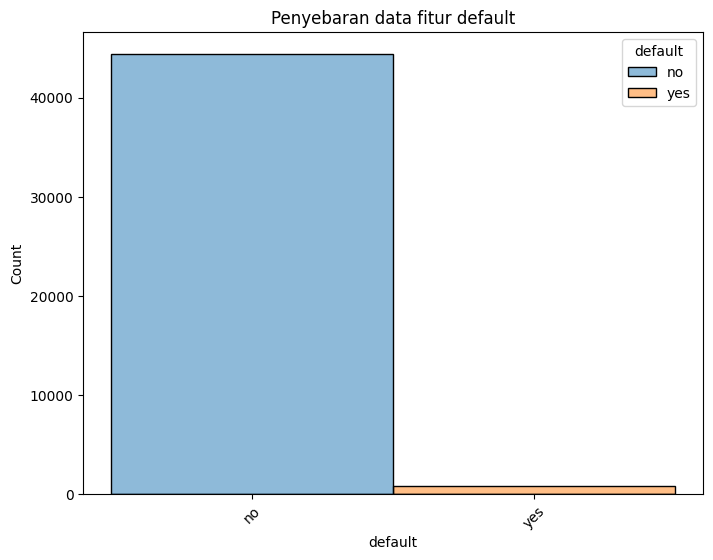

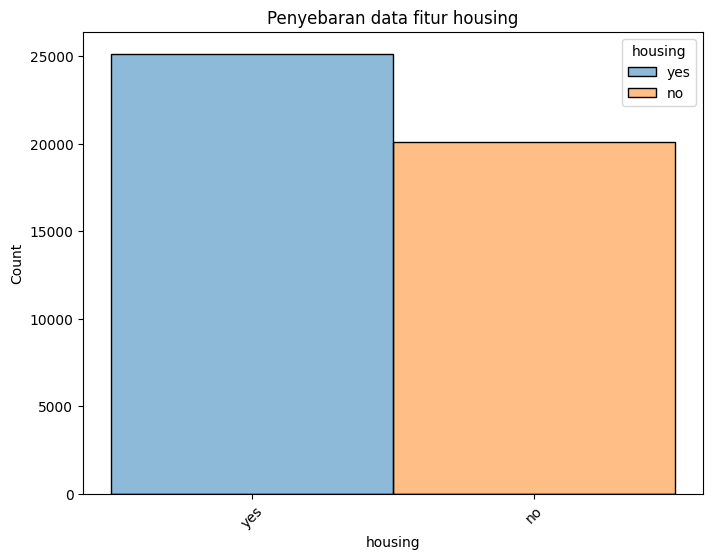

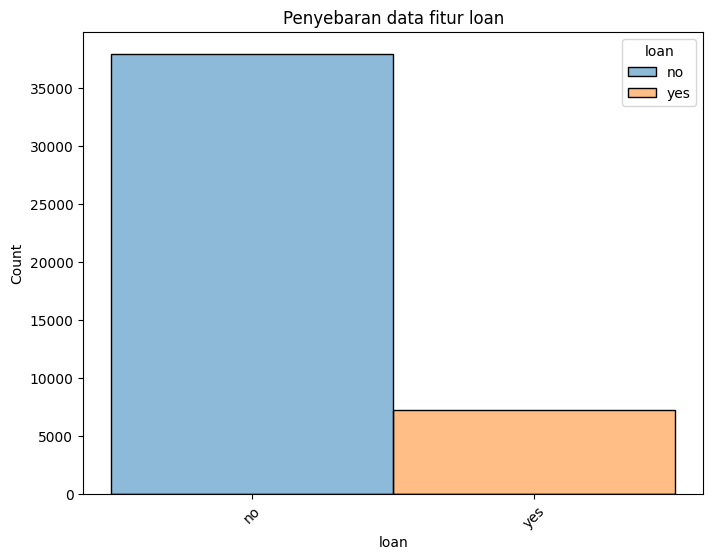

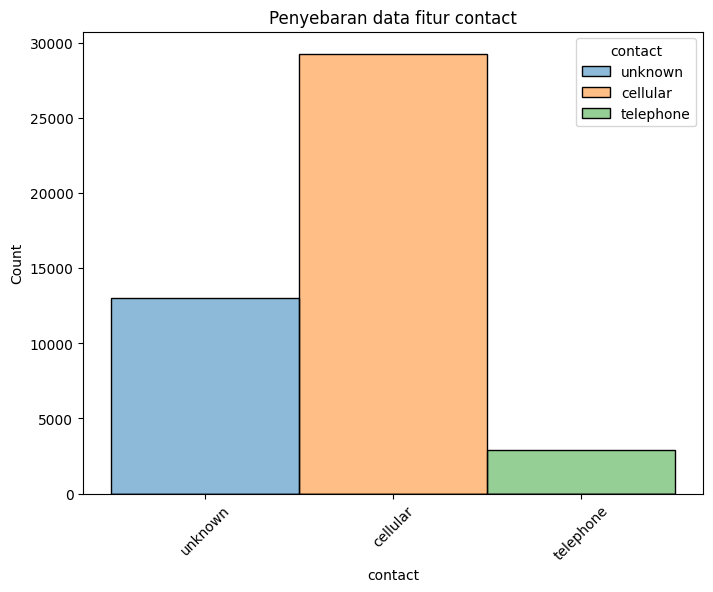

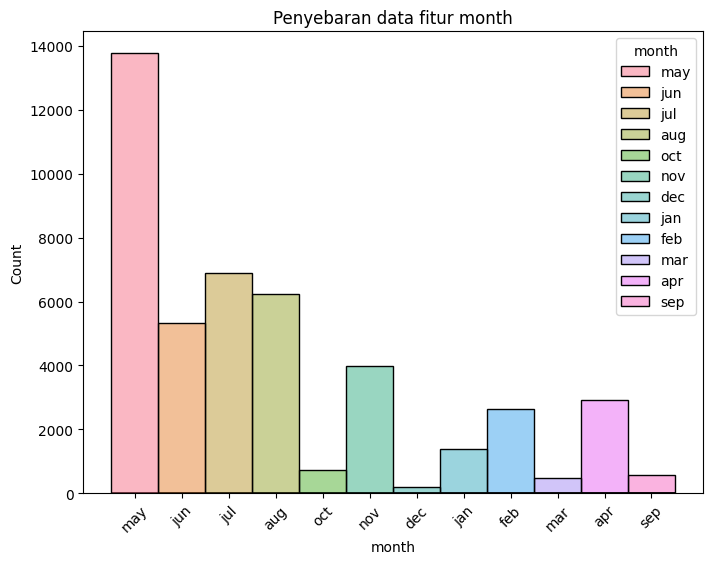

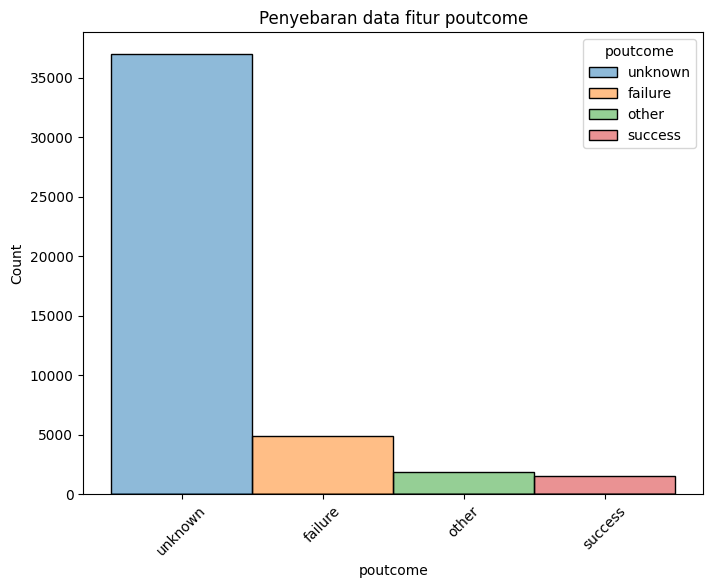

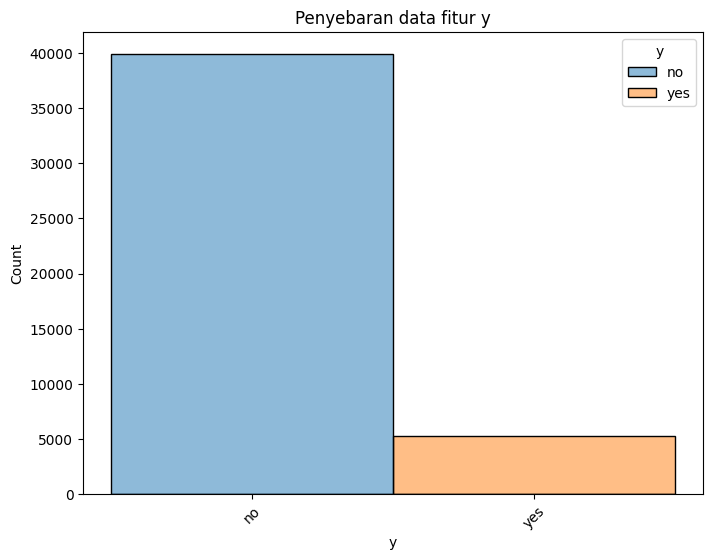

In [19]:
# penyebaran data kategori
for col in cat_cols:
    plt.figure(figsize=(8,6))
    plt.xticks(rotation=45)
    sns.histplot(x=assignment[col], hue=assignment[col])
    plt.title(f'Penyebaran data fitur {col}')
    plt.show()

#### 1.4.3 Outlier pada Fitur

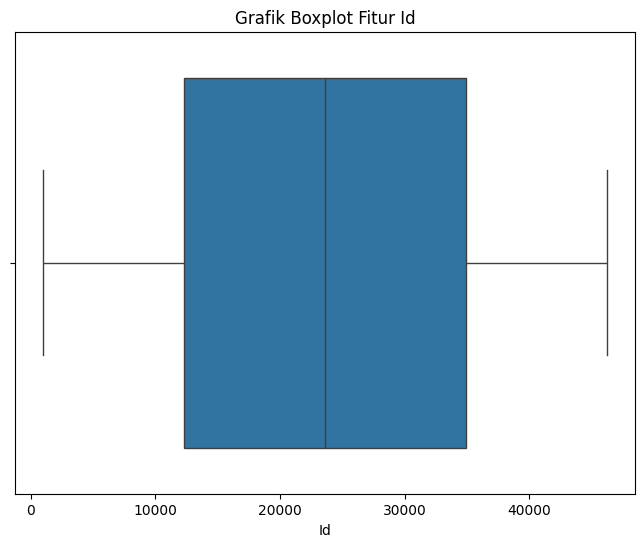

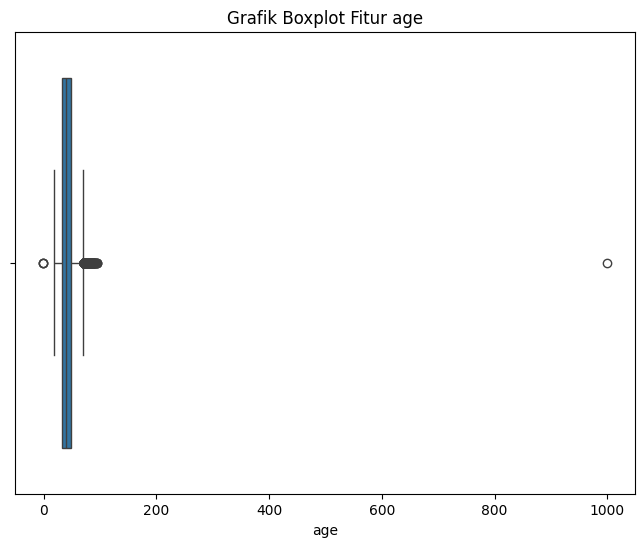

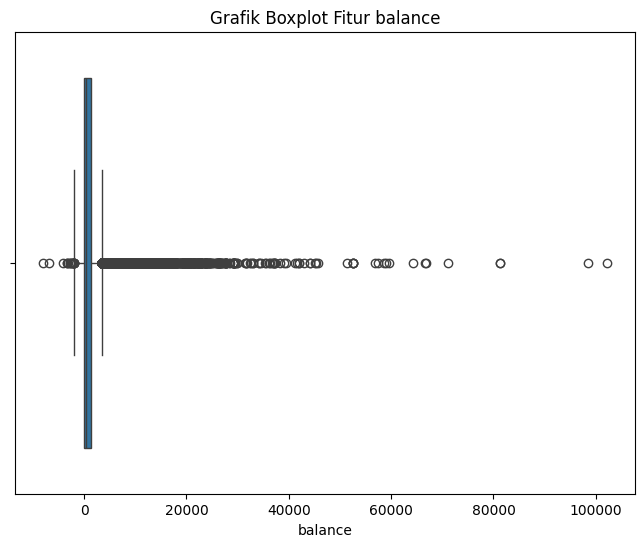

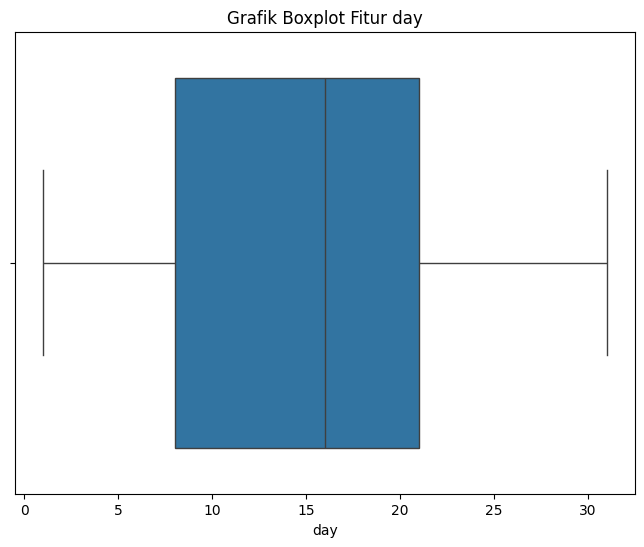

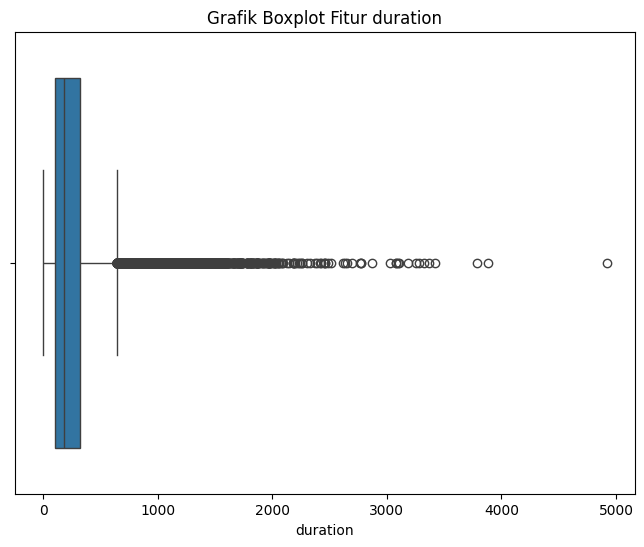

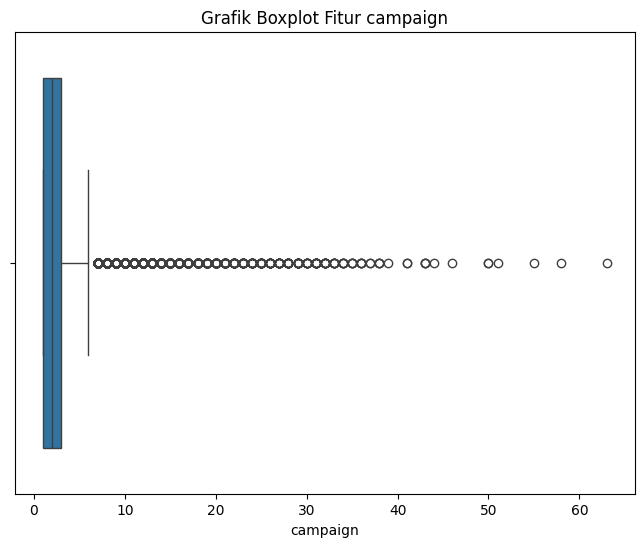

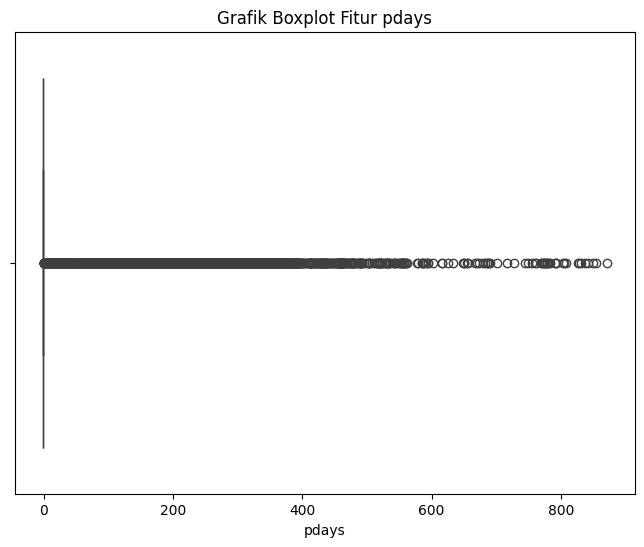

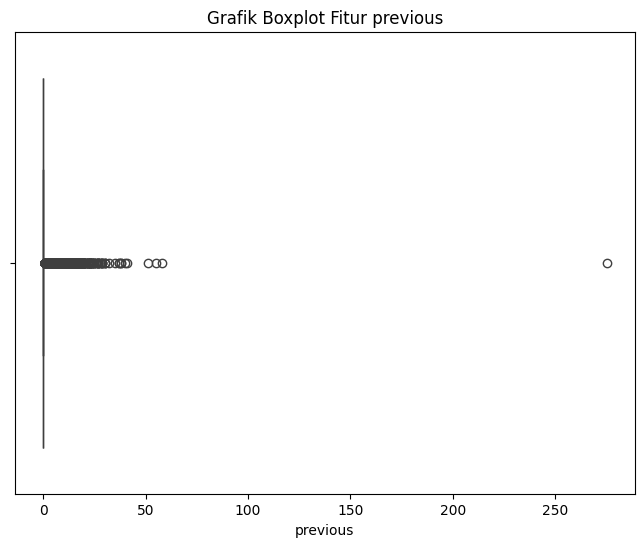

In [20]:
# Tampilkan outlier per fitur
for col in num_cols:
    plt.figure(figsize=(8,6))
    sns.boxplot(x=assignment[col])
    plt.title(f'Grafik Boxplot Fitur {col}')
    plt.show()

Penyebaran fitur tidak merata, cenderung skew ke kanan.

#### 1.4.4 Korelasi antar Fitur

In [21]:
correlation = assignment.select_dtypes(include=np.number).corr()
correlation

,Id,age,balance,day,duration,campaign,pdays,previous
Id,1.000000,0.010182,0.073605,-0.061465,0.013031,-0.102884,0.437729,0.271098
age,0.010182,1.000000,0.090419,-0.010820,-0.004389,0.003452,-0.022584,0.000289
balance,0.073605,0.090419,1.000000,0.004471,0.021554,-0.014592,0.003425,0.016668
day,-0.061465,-0.010820,0.004471,1.000000,-0.030206,0.162490,-0.093044,-0.051710
duration,0.013031,-0.004389,0.021554,-0.030206,1.000000,-0.084570,-0.001565,0.001203
campaign,-0.102884,0.003452,-0.014592,0.162490,-0.084570,1.000000,-0.088628,-0.032855
pdays,0.437729,-0.022584,0.003425,-0.093044,-0.001565,-0.088628,1.000000,0.454820
previous,0.271098,0.000289,0.016668,-0.051710,0.001203,-0.032855,0.454820,1.000000


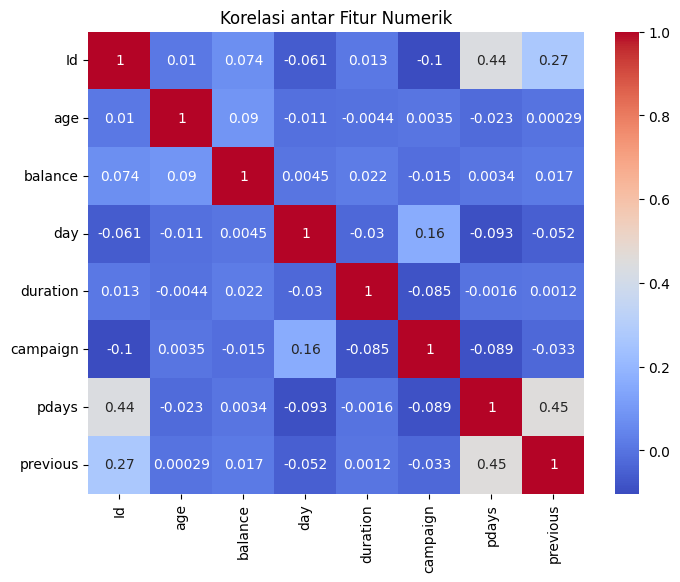

In [22]:
# Grafik heatmap
plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Korelasi antar Fitur Numerik')
plt.show()

### 1.5 Data Cleaning

#### 1.5.1 Menangani Missing Value

In [23]:
assignment = assignment.dropna()

In [24]:
print('Total missing value setelah ditangani', assignment.isnull().sum().sum())

Total missing value setelah ditangani 0


#### 1.5.2 Encoding Fitur Objek

In [25]:
# Encoding fitur 'job'
assignment['job'] = assignment['job'].map({
    'management': 0,
    'technician': 1,
    'entrepreneur': 2,
    'blue-collar':3,
    'unknown': 4,
    'admin': 5,
    'services': 6,
    'retired': 7,
    'self-employed': 8,
    'unemployed': 9,
    'housemaid': 10,
    'student': 11
})


In [26]:
# Encoding fitur 'marital'
assignment['marital'] = assignment['marital'].map({
    'married': 0,
    'single': 1,
    'divorced': 2,
})

In [27]:
# encoding fitur 'education'
assignment['education'] = assignment['education'].map({
    'tertiary': 0,
    'secondary': 1,
    'unknown': 2,
    'primary': 3,
})

In [28]:
# encoding fitur 'defult'
assignment['default'] = assignment['default'].map({
    'no': 0,
    'yes':1
})

In [29]:
# encoding fitur 'housing'
assignment['housing'] = assignment['housing'].map({
    'no': 0,
    'yes': 1
})

In [30]:
# encoding fitur 'loan'
assignment['loan'] = assignment['loan'].map({
    'no': 0,
    'yes': 1
})

In [31]:
assignment['contact'] = assignment['contact'].map({
    'unknown': 0,
    'cellular': 1,
    'telephone':2
    })

In [32]:
# Encoding fitur 'month'
assignment['month'] = assignment['month'].map({
    'jan': 0,
    'feb': 1,
    'mar': 2,
    'apr':3,
    'may': 4,
    'jun': 5,
    'jul': 6,
    'agu': 7,
    'sep': 8,
    'oct': 9,
    'nov': 10,
    'dec': 11
})


In [33]:
# encoding fitur 'poutcome'
assignment['poutcome'] = assignment['poutcome'].map({
    'unknown': 0,
    'failure': 1,
    'other': 2,
    'success': 3,
})

In [34]:
# encoding gitur'y'
assignment['y'] = assignment['y'].map({
    'no': 0,
    'yes': 1
})

In [35]:
assignment.head()

,Id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,1001,999.0,0.0,0,0,0,2143.0,1,0,0,5,4.0,261,1,-1,0,0,0
1,1002,44.0,1.0,1,1,0,29.0,1,0,0,5,4.0,151,1,-1,0,0,0
2,1003,33.0,2.0,0,1,0,2.0,1,1,0,5,4.0,76,1,-1,0,0,0
3,1004,47.0,3.0,0,2,0,1506.0,1,0,0,5,4.0,92,1,-1,0,0,0
4,1005,33.0,4.0,1,2,0,1.0,0,0,0,5,4.0,198,1,-1,0,0,0


## **MODEL**

In [36]:
X_before = assignment.drop(['Id', 'age'], axis=1)
y = assignment['y']

In [37]:
# normalisasi (X - X.min) / (X.max - X.min)
X = (X_before - X_before.min()) / (X_before.max() - X_before.min())

# standarisasi (X - X.mean) / X - X.std
# X =(X_before - X_before.mean()) / X_before - X_before.std()

In [38]:
np.random.seed(42)

idx_0 = np.where(y == 0)[0]
idx_1 = np.where(y == 1)[0]

np.random.shuffle(idx_0)
np.random.shuffle(idx_1)

train_0 = int(len(idx_0) * 0.8)
train_1 = int(len(idx_1) * 0.8)

train_idx = np.concatenate([idx_0[:train_0], idx_1[:train_1]])
test_idx = np.concatenate([idx_0[train_0:], idx_1[train_1:]])

np.random.shuffle(train_idx)
np.random.shuffle(test_idx)

X_train = X.iloc[train_idx].values
y_train = y.iloc[train_idx].values
X_test = X.iloc[test_idx].values
y_test = y.iloc[test_idx].values

In [39]:
def knn(X_train, y_train, X_test, k=3, p=2, weight='uniform'):
    n_test = X_test.shape[0]
    distances = np.zeros((n_test, X_train.shape[0]))
    for i in range(n_test):
        distances[i] = np.sum(np.abs(X_train - X_test[i])**p, axis=1)**(1/p)
    
    votes_all = []
    for i in range(n_test):
        dist = distances[i]
        sort = np.argsort(dist)
        nearest = sort[:k]
        nearest_label = y_train[nearest]
        nearest_distance = dist[nearest]
        
        if weight == 'uniform':
            votes = np.bincount(nearest_label, minlength=np.max(y_train) + 1)
        elif weight == 'weighted':
            weights = 1 / (nearest_distance + 1e-5)
            votes = np.zeros(np.max(y_train) + 1)
            for j in range(len(nearest_label)):
                votes[nearest_label[j]] += weights[j]
        
        votes_all.append(votes)
    
    return np.array(votes_all)

In [40]:
# mencari weight terbaik

vote_method =['uniform', 'weighted']
best_weight = {}

for method in vote_method:
    correct = 0
    for i in range(len(X_test)):
        pred = knn(X_train, y_train, X_test[i], k=5, p=2, weight=method)
        predicted_label = np.argmax(pred)
        if predicted_label == y_test[i]:
            correct += 1
    acc = correct / len(X_test)
    best_weight[method] = acc
    print(f'method {method}, acc: {acc:.4f}')
# print(f'')

KeyboardInterrupt: 

In [ ]:
# tune k terbaik

k_range = [3,5,7,9,11]
best_k = {}

for k in k_range:
    correct = 0
    for i in range(len(X_test)):
        pred = knn(X_train, y_train, X_test[i:i+1], k=k, p=2, weight='uniform')[0]
        predicted_label = np.argmax(pred)
        if predicted_label == y_test[i]:
            correct += 1
    acc = correct / len(X_test)
    best_k[k] = acc
    print(f'k: {k}, acc: {acc:.4f}')

best_k_value = max(best_k, key=best_k.get)

k: 3, acc: 0.9716
k: 5, acc: 0.9716
k: 7, acc: 0.9716
k: 9, acc: 0.9716
k: 11, acc: 0.9716


In [ ]:
def evaluate(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    accuracy = (tp + tn) / len(y_true)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    return accuracy, precision, recall, f1_score

In [ ]:
pred_eulidean = knn(X_train, y_train, X_test, k=best_k_value, p=2, weight='uniform')
pred_manhattan = knn(X_train, y_train, X_test, k=best_k_value, p=1, weight='uniform')
pred_chebyshev = knn(X_train, y_train, X_test, k=best_k_value, p=np.inf, weight='uniform')

# Prediksi Train
y_train_pred_eulidean = np.argmax(knn(X_train, y_train, X_train, k=best_k_value, p=2, weight='uniform'), axis=1)
y_train_pred_manhattan = np.argmax(knn(X_train, y_train, X_train, k=best_k_value, p=1, weight='uniform'), axis=1)
y_train_pred_chebyshev = np.argmax(knn(X_train, y_train, X_train, k=best_k_value, p=np.inf, weight='uniform'), axis=1)

acc_train_eu, precision_train_eu, recall_train_eu, f1_train_eu = evaluate(y_train, y_train_pred_eulidean)
acc_train_ma, precision_train_ma, recall_train_ma, f1_train_ma = evaluate(y_train, y_train_pred_manhattan)
acc_train_ch, precision_train_ch, recall_train_ch, f1_train_ch = evaluate(y_train, y_train_pred_chebyshev)

# Prediksi Tes

y_pred_eulidean = np.argmax(pred_eulidean, axis=1)
y_pred_manhattan = np.argmax(pred_manhattan, axis=1)
y_pred_chebyshev = np.argmax(pred_chebyshev, axis=1)

accuracy_eu, precision_eu, recall_eu, f1_eu = evaluate(y_test, y_pred_eulidean)
accuracy_ma, precision_ma, recall_ma, f1_ma = evaluate(y_test, y_pred_manhattan)
accuracy_ch, precision_ch, recall_ch, f1_ch = evaluate(y_test, y_pred_chebyshev)

print('Prediksi Train')
print(f'Euclidean - Accuracy: {acc_train_eu:.4f}, Precision: {precision_train_eu:.4f}, Recall: {recall_train_eu:.4f}, F1 Score: {f1_train_eu:.4f}')
print(f'Manhattan - Accuracy: {acc_train_ma:.4f}, Precision: {precision_train_ma:.4f}, Recall: {recall_train_ma:.4f}, F1 Score: {f1_train_ma:.4f}')
print(f'Chebyshev - Accuracy: {acc_train_ch:.4f}, Precision: {precision_train_ch:.4f}, Recall: {recall_train_ch:.4f}, F1 Score: {f1_train_ch:.4f}')

print('\nPrediksi Test')
print(f'Euclidean - Accuracy: {accuracy_eu:.4f}, Precision: {precision_eu:.4f}, Recall: {recall_eu:.4f}, F1 Score: {f1_eu:.4f}')
print(f'Manhattan - Accuracy: {accuracy_ma:.4f}, Precision: {precision_ma:.4f}, Recall: {recall_ma:.4f}, F1 Score: {f1_ma:.4f}')
print(f'Chebyshev - Accuracy: {accuracy_ch:.4f}, Precision: {precision_ch:.4f}, Recall: {recall_ch:.4f}, F1 Score: {f1_ch:.4f}')